# BTC — Detrending analysis (figura para el TFM)

Este notebook genera una figura tipo “detrending analysis” (precio, tendencia por media móvil, serie detrendida y retorno detrendido) a partir del CSV local.

Entrada:
- `experimentos/data/btc_binance_ohlcv_1d.csv`

Salida:
- `figuras/marco_teorico/fig_3_7_detrending_analysis_period2.png`

Salida adicional (elaboración propia):
- `figuras/marco_teorico/fig_3_2_eficiencia_regimenes_bitcoin.png`
- `figuras/marco_teorico/fig_3_3_distribucion_log_return_btc.png`
- `figuras/marco_teorico/fig_3_8_ohlcv_indicadores_btc.png`
- `figuras/datos/fig_8_1_close_volume_serie.png`
- `figuras/datos/fig_8_2_missing_values_derived.png`


In [14]:
import sys, subprocess, importlib
for p in ["pandas","numpy","matplotlib"]:
    try:
        importlib.import_module(p)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", p])
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pathlib

In [15]:
def find_csv_path():
    cwd = pathlib.Path.cwd().resolve()
    candidates = [
        cwd / "experimentos" / "data" / "btc_binance_ohlcv_1d.csv",
        cwd / "data" / "btc_binance_ohlcv_1d.csv",
        cwd.parent / "experimentos" / "data" / "btc_binance_ohlcv_1d.csv",
        cwd.parent / "data" / "btc_binance_ohlcv_1d.csv",
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError("No se encontró btc_binance_ohlcv_1d.csv. Candidatos: " + ", ".join(str(p) for p in candidates))

csv_path = find_csv_path()
csv_path

PosixPath('/Users/williamvasquez/Library/CloudStorage/OneDrive-Personal/Documentos/William/cursos Online/Masters/IA VIU/trabajo fin master/proyecto_grado/experimentos/data/btc_binance_ohlcv_1d.csv')

In [16]:
df = pd.read_csv(csv_path)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values("timestamp").reset_index(drop=True)
df[["timestamp","open","high","low","close","volume"]].head()

,timestamp,open,high,low,close,volume
0,2017-08-18 00:00:00+00:00,4285.08,4371.52,3938.77,4108.37,1199.888264
1,2017-08-19 00:00:00+00:00,4108.37,4184.69,3850.00,4139.98,381.309763
2,2017-08-20 00:00:00+00:00,4120.98,4211.08,4032.62,4086.29,467.083022
3,2017-08-21 00:00:00+00:00,4069.13,4119.62,3911.79,4016.00,691.743060
4,2017-08-22 00:00:00+00:00,4016.00,4104.82,3400.00,4040.00,966.684858


In [17]:
ma_window = 30

d = df.copy()
d["trend"] = d["close"].rolling(ma_window, min_periods=ma_window).mean()
d = d.dropna(subset=["trend"]).copy()
d["detrended_index"] = d["close"] - d["trend"]
d["detrended_return"] = d["detrended_index"].diff()
d[["timestamp","close","trend","detrended_index","detrended_return"]].head()

,timestamp,close,trend,detrended_index,detrended_return
29,2017-09-16 00:00:00+00:00,3714.95,4239.663667,-524.713667,NaN
30,2017-09-17 00:00:00+00:00,3699.99,4226.051000,-526.061000,-1.347333
31,2017-09-18 00:00:00+00:00,4035.01,4222.552000,-187.542000,338.519000
32,2017-09-19 00:00:00+00:00,3910.04,4216.677000,-306.637000,-119.095000
33,2017-09-20 00:00:00+00:00,3900.00,4212.810333,-312.810333,-6.173333


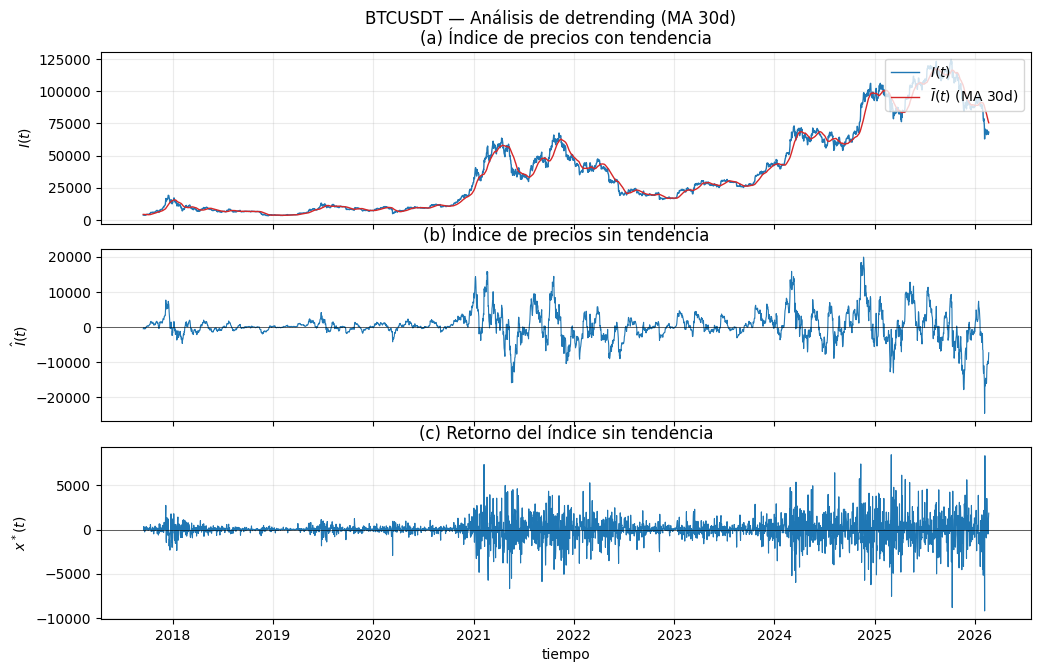

'/Users/williamvasquez/Library/CloudStorage/OneDrive-Personal/Documentos/William/cursos Online/Masters/IA VIU/trabajo fin master/proyecto_grado/figuras/marco_teorico/fig_3_7_detrending_analysis_period2.png'

In [18]:
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25})
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True, gridspec_kw={"hspace": 0.15})

axes[0].plot(d["timestamp"], d["close"], label=r"$I(t)$", color="tab:blue", linewidth=1)
axes[0].plot(d["timestamp"], d["trend"], label=f"$\\bar{{I}}(t)$ (MA {ma_window}d)", color="tab:red", linewidth=1)
axes[0].set_ylabel(r"$I(t)$")
axes[0].set_title("(a) Índice de precios con tendencia")
axes[0].legend(loc="upper right")

axes[1].plot(d["timestamp"], d["detrended_index"], color="tab:blue", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=0.7, alpha=0.6)
axes[1].set_ylabel(r"$\hat{I}(t)$")
axes[1].set_title("(b) Índice de precios sin tendencia")

axes[2].plot(d["timestamp"], d["detrended_return"], color="tab:blue", linewidth=0.8)
axes[2].axhline(0, color="black", linewidth=0.7, alpha=0.6)
axes[2].set_ylabel(r"$x^*(t)$")
axes[2].set_xlabel("tiempo")
axes[2].set_title("(c) Retorno del índice sin tendencia")

project_root = csv_path.parents[2]
out_dir = (project_root / "figuras" / "marco_teorico").resolve()
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "fig_3_7_detrending_analysis_period2.png"
fig.suptitle(f"BTCUSDT — Análisis de detrending (MA {ma_window}d)")
fig.subplots_adjust(top=0.92)
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
str(out_path)

## Figuras propias adicionales para el TFM

Esta sección genera figuras reproducibles para el marco teórico (secciones 3.2, 3.3 y 3.4) a partir del CSV local.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

close = df['close'].astype(float)
log_close = np.log(close)
log_return = log_close.diff()

out_dir = (csv_path.parents[2] / 'figuras' / 'marco_teorico').resolve()
out_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.25})

vol_30 = log_return.rolling(30, min_periods=30).std() * np.sqrt(365.0)
vol_thr = float(vol_30.dropna().quantile(0.75))
x = df['timestamp']
mask = (vol_30 > vol_thr).fillna(False).to_numpy()
mask_idx = np.where(mask)[0]
segments = []
if mask_idx.size:
    start = mask_idx[0]
    prev = mask_idx[0]
    for i in mask_idx[1:]:
        if i == prev + 1:
            prev = i
            continue
        segments.append((start, prev))
        start = i
        prev = i
    segments.append((start, prev))

fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True, gridspec_kw={'hspace': 0.15})
axes[0].plot(x, close, color='tab:blue', linewidth=1.0, label='Cierre (close)')
axes[0].set_yscale('log')
axes[0].set_ylabel('Precio (escala log)')
axes[0].set_title('(a) Precio de cierre')
for a, b in segments:
    axes[0].axvspan(x.iloc[a], x.iloc[b], color='tab:red', alpha=0.08)
axes[1].plot(x, vol_30, color='tab:orange', linewidth=1.0, label='Volatilidad móvil (30d, anualizada)')
axes[1].axhline(vol_thr, color='tab:red', linewidth=1.0, alpha=0.8, label='Umbral (p75)')
axes[1].set_ylabel('Volatilidad')
axes[1].set_xlabel('Tiempo')
axes[1].set_title('(b) Proxy de cambios de régimen: volatilidad móvil')
axes[1].legend(loc='upper right')
fig.suptitle('BTCUSDT — No estacionariedad y cambios de régimen (elaboración propia)')
fig.subplots_adjust(top=0.90)
out_path = out_dir / 'fig_3_2_eficiencia_regimenes_bitcoin.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

r = log_return.dropna().to_numpy()
bins = np.linspace(-0.20, 0.20, 161)
mu = float(np.mean(r))
sigma = float(np.std(r, ddof=1))
xs = np.linspace(bins.min(), bins.max(), 1000)
pdf = (1.0 / (sigma * np.sqrt(2.0 * np.pi))) * np.exp(-0.5 * ((xs - mu) / sigma) ** 2)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
axes[0].hist(r, bins=bins, density=True, color='tab:blue', alpha=0.55, label='Empírica')
axes[0].plot(xs, pdf, color='tab:red', linewidth=1.2, label='Normal (misma media y desv.)')
axes[0].set_title('(a) Escala lineal')
axes[0].set_ylabel('Densidad')
axes[0].set_xlabel('Retorno logarítmico diario')
axes[0].legend(loc='upper right')
axes[1].hist(r, bins=bins, density=True, color='tab:blue', alpha=0.55)
axes[1].plot(xs, pdf, color='tab:red', linewidth=1.2)
axes[1].set_yscale('log')
axes[1].set_title('(b) Escala log en densidad')
axes[1].set_xlabel('Retorno logarítmico diario')
fig.suptitle('BTCUSDT — Distribución de retornos logarítmicos y colas pesadas (elaboración propia)')
fig.subplots_adjust(top=0.85)
out_path = out_dir / 'fig_3_3_distribucion_log_return_btc.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

sample_days = 240
sub = df.tail(sample_days).copy()
sub['sma_20'] = sub['close'].rolling(20, min_periods=20).mean()
sub['sma_100'] = sub['close'].rolling(100, min_periods=100).mean()
sub['range_hl'] = sub['high'] - sub['low']
sub['range_hl_ma_14'] = sub['range_hl'].rolling(14, min_periods=14).mean()
sub['vol_ma_20'] = sub['volume'].rolling(20, min_periods=20).mean()
fig, axes = plt.subplots(3, 1, figsize=(12, 7.0), sharex=True, gridspec_kw={'hspace': 0.15})
axes[0].plot(sub['timestamp'], sub['close'], color='tab:blue', linewidth=1.0, label='close')
axes[0].plot(sub['timestamp'], sub['sma_20'], color='tab:orange', linewidth=1.0, label='SMA 20')
axes[0].plot(sub['timestamp'], sub['sma_100'], color='tab:green', linewidth=1.0, label='SMA 100')
axes[0].set_ylabel('Precio')
axes[0].set_title('(a) close y medias móviles')
axes[0].legend(loc='upper left', ncol=3)
axes[1].plot(sub['timestamp'], sub['range_hl'], color='tab:purple', linewidth=0.9, label='high-low')
axes[1].plot(sub['timestamp'], sub['range_hl_ma_14'], color='tab:red', linewidth=1.0, label='MA 14')
axes[1].set_ylabel('Rango')
axes[1].set_title('(b) Rango diario (high-low)')
axes[1].legend(loc='upper left', ncol=2)
axes[2].bar(sub['timestamp'], sub['volume'], color='tab:gray', alpha=0.5, width=1.0, label='volume')
axes[2].plot(sub['timestamp'], sub['vol_ma_20'], color='tab:blue', linewidth=1.0, label='MA 20')
axes[2].set_ylabel('Volumen')
axes[2].set_xlabel('Tiempo')
axes[2].set_title('(c) Volumen y media móvil')
axes[2].legend(loc='upper left', ncol=2)
for ax in axes:
    ax.grid(True, alpha=0.25)
fig.suptitle('BTCUSDT — Ejemplo de OHLCV e indicadores técnicos derivados (elaboración propia)')
fig.subplots_adjust(top=0.92)
out_path = out_dir / 'fig_3_8_ohlcv_indicadores_btc.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
str(out_dir)


## Figuras para el capítulo 8

figuras descriptivas del dataset a partir del CSV


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25})

if "csv_path" not in globals():
    raise NameError("Ejecuta primero la celda que define csv_path.")

d = pd.read_csv(csv_path)
if "timestamp" in d.columns:
    d["timestamp"] = pd.to_datetime(d["timestamp"], utc=True, errors="coerce")
d = d.sort_values("timestamp")

out_dir = (Path.cwd().resolve() / "figuras" / "datos")
out_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 1, figsize=(12, 6.8), sharex=True, gridspec_kw={"hspace": 0.15})
axes[0].plot(d["timestamp"], d["close"].astype(float), color="tab:blue", linewidth=1.0)
axes[0].set_yscale("log")
axes[0].set_ylabel("close (log)")
axes[0].set_title("(a) Precio de cierre (escala log)")
axes[1].bar(d["timestamp"], d["volume"].astype(float), color="tab:gray", alpha=0.45, width=1.0)
axes[1].set_ylabel("volume")
axes[1].set_xlabel("Tiempo (UTC)")
axes[1].set_title("(b) Volumen diario")
fig.suptitle("BTCUSDT — Cobertura temporal del dataset (elaboración propia)")
fig.subplots_adjust(top=0.90)
p1 = out_dir / "fig_8_1_close_volume_serie.png"
fig.savefig(p1, dpi=300, bbox_inches="tight")
plt.show()

nan_counts = d.isna().sum().sort_values(ascending=False)
nan_counts = nan_counts[nan_counts > 0]

fig, ax = plt.subplots(1, 1, figsize=(12, 4.8))
ax.bar(nan_counts.index.astype(str), nan_counts.values, color="tab:orange", alpha=0.8)
ax.set_ylabel("Número de valores no definidos")
ax.set_title("Valores no definidos por columna (por construcción de derivados)")
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
p2 = out_dir / "fig_8_2_missing_values_derived.png"
fig.savefig(p2, dpi=300, bbox_inches="tight")
plt.show()

(str(p1), str(p2))
